### Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the process of examining and visualizing a dataset to understand its structure, patterns, and relationships before applying modeling or statistical techniques. In EDA projects, analysts use summary statistics, charts, and plots to uncover trends, detect anomalies, test assumptions, and gain insights that guide further data preprocessing, feature selection, or hypothesis generation.

Steps for an Exploratory Data Analysis (EDA) Project

1. Data Collection

* Gather data from sources such as CSV files,Excel files or databases.

* Ensure data is relevant, up to date, and in a usable format.

2. Data Cleaning

* Handle missing values (e.g., drop, impute).

* Remove or correct duplicate records.

* Fix inconsistent formatting (e.g., date formats, text casing).

* Handle incorrect data entries or outliers.

* Standardize categorical values (e.g., “Yes”, “yes”, “Y”).
3. Data Understanding

* Review column types and data structure.

* Use summary statistics to understand distributions.

* Identify categorical vs. numerical features.

* Perform sanity checks (e.g., no negative prices, date logic).

4. Univariate Analysis

* Analyze one feature at a time:

   1.Categorical: frequency counts, bar charts.

   2.Numerical: mean, median, histograms, boxplots.


5. Bivariate Analysis

* Explore relationships between two variables:

   1.Categorical vs. categorical (cross-tabulation).

   2.Numerical vs. categorical (grouped statistics, boxplots).

   3.Numerical vs. numerical (scatter plots, correlation).

6. Multivariate Analysis

* Analyze interactions between three or more variables.

Use groupings, pivot tables, or visualizations like pairplots and heatmaps.

7. Feature Engineering

* Create new variables from existing data (e.g., total profit, sales per unit).

* Convert date/time into useful parts (month, weekday).

* Encode categorical variables if needed (for modeling).

8. Outlier Detection

* Identify and assess outliers using statistical or visual methods.

* Decide whether to keep, transform, or remove them based on context.

9. Trend and Pattern Analysis

* Use time series plots to detect seasonal or time-based patterns.

* Segment analysis by region, product category, customer type, etc.

10. Documentation & Reporting

Summarize findings with visualizations and insights.

Clearly communicate actionable recommendations.

Highlight data quality issues and limitations.

### EV Purchase Analysis — Understanding the Factors Influencing Electric Vehicle Adoption

Business Problem:
An EV company wants to understand which customer characteristics and concerns influence a person's decision to purchase an electric vehicle. By analyzing customer demographics, income, commuting distance, environmental concerns, and range anxiety, the company can identify potential EV buyers and improve its marketing strategy.

## Introduction

The adoption of Electric Vehicles (EVs) is increasing as people and organizations look for more sustainable and environmentally friendly transportation options. However, the decision to purchase an EV can be influenced by several factors such as income, daily commuting distance, environmental awareness, and concerns about vehicle range.

This project focuses on analyzing customer data to understand the factors that may influence EV purchase decisions. Using Python, Pandas, NumPy, Matplotlib, Seaborn, and Exploratory Data Analysis (EDA) techniques, the project explores customer characteristics, identifies patterns and relationships in the data, and generates meaningful insights.

The main objective of this project is to help an EV company better understand its potential customers and identify factors that can support effective customer targeting and marketing strategies.

#### Data Collection and Understanding

In [24]:
# To remove the warning messages
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# Read the csv file and print its shape (rows,colums)
df=pd.read_csv("E:/SMEC/workspace/EV_Purchase_DataAnalysis_Project/EV_Adoption_and_Range_Anxiety_Dataset.csv")
print(df.shape)

(10000, 15)


In [26]:
print(df.head())  

  Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0  EV00001   56    Male            44906.0     Rural              18.1   
1  EV00002   36    Male            88754.0     Rural               5.0   
2  EV00003   42    Male           155958.0     Urban              32.2   
3  EV00004   31    Male            37059.0     Rural              89.9   
4  EV00005   48  Female            48552.0     Rural              71.0   

   Number_of_Cars_Owned Current_Car_Type  Charging_Stations_Near_Home  \
0                     1            Truck                            1   
1                     1              SUV                            2   
2                     2            Sedan                           14   
3                     1            Sedan                            2   
4                     1            Sedan                            2   

   Charging_Stations_Near_Work Home_Charging_Possible  \
0                            0                    Yes   
1 

In [27]:
print(df.tail())

     Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
9995  EV09996   50    Male            61279.0     Urban              71.4   
9996  EV09997   34    Male           108208.0     Urban              48.0   
9997  EV09998   60  Female            97743.0     Urban               9.0   
9998  EV09999   31  Female           103628.0     Urban              81.8   
9999  EV10000   64   Other            59052.0  Suburban              24.0   

      Number_of_Cars_Owned Current_Car_Type  Charging_Stations_Near_Home  \
9995                     1            Sedan                            8   
9996                     2        Hatchback                            9   
9997                     2            Sedan                           10   
9998                     2              SUV                           10   
9999                     2        Hatchback                            1   

      Charging_Stations_Near_Work Home_Charging_Possible  \
9995                

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

In [29]:
print(df.describe())

                Age  Annual_Income_USD  Daily_Commute_km  \
count  10000.000000        9822.000000       9819.000000   
mean      46.936200       85378.485848         41.105418   
std       12.945968       32838.684167         23.351276   
min       25.000000       30000.000000          5.000000   
25%       36.000000       61369.500000         23.250000   
50%       47.000000       84708.000000         40.200000   
75%       58.000000      107383.250000         57.000000   
max       69.000000      223345.000000        135.500000   

       Number_of_Cars_Owned  Charging_Stations_Near_Home  \
count          10000.000000                 10000.000000   
mean               1.859900                     5.346900   
std                0.855421                     4.049074   
min                1.000000                     0.000000   
25%                1.000000                     2.000000   
50%                2.000000                     5.000000   
75%                2.000000            

In [30]:
# The colums Will_buy_EV,Subsidy_Available,Home_Charging_Possible,Range_Anxiety_Level are not numerical
# We need to add new numerical colums to analyze the data otherwise groupby,mean,median will not work


df['Buy_Flag'] = (df['Will_Buy_EV'] == 'Yes').astype(int)
df['Subsidy_Flag'] = (df['Subsidy_Available'] == 'Yes').astype(int)
df['HomeCharge_Flag'] = (df['Home_Charging_Possible'] == 'Yes').astype(int)
df['Range_Anxiety_Num'] = df['Range_Anxiety_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

### Data Cleaning

In [31]:
# To identify missing values
print(df.isnull().sum())

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
Buy_Flag                         0
Subsidy_Flag                     0
HomeCharge_Flag                  0
Range_Anxiety_Num                0
dtype: int64


- 178 missing rows Annual_Income_USD
- 181 missing rows Daily_Commute_km
- 184 missing rows Environmental_Concern_Level
All are numerical values

In [32]:
# Data Cleaning
# Fill Numerical datas with median because mean is much affected by extreme high and low values in this dataset

df['Annual_Income_USD'] = df['Annual_Income_USD'].fillna(df['Annual_Income_USD'].median())

df['Daily_Commute_km'] = df['Daily_Commute_km'].fillna(df['Daily_Commute_km'].median())

df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].fillna(df['Environmental_Concern_Level'].median())

# Verify whether Data is cleaned by fixing mixing values
print(df.isnull().sum())

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level    0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
Buy_Flag                       0
Subsidy_Flag                   0
HomeCharge_Flag                0
Range_Anxiety_Num              0
dtype: int64


In [33]:
print(df.shape)

(10000, 19)


In [34]:
print(df.duplicated().sum())


0


In [35]:
# Buyer_ID represent the each customer should be unique(Since it is a primary key)
df['Buyer_ID'].nunique()

10000

So 10000 means all are unique entries
Now our data is clean✅

### Data Analysing

In [36]:
' 1. How many customers will buy Electrical Vehicle(EV)? '

df['Will_Buy_EV'].value_counts()['Yes']

# Here yes means buy the EV and value_counts() counts it

1750

So 1750 members out of 10000 buys EV

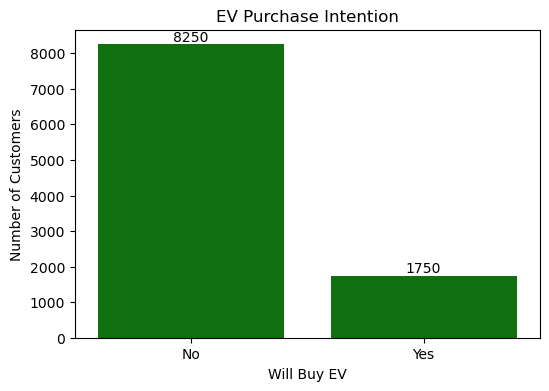

In [37]:
# Graphically visuvalize above data

plt.figure(figsize=(6, 4))

ax=sns.countplot(data=df, x='Will_Buy_EV',color='green')

plt.title('EV Purchase Intention')
plt.xlabel('Will Buy EV')
plt.ylabel('Number of Customers')

for item in ax.containers:
    ax.bar_label(item)

plt.show()

[]

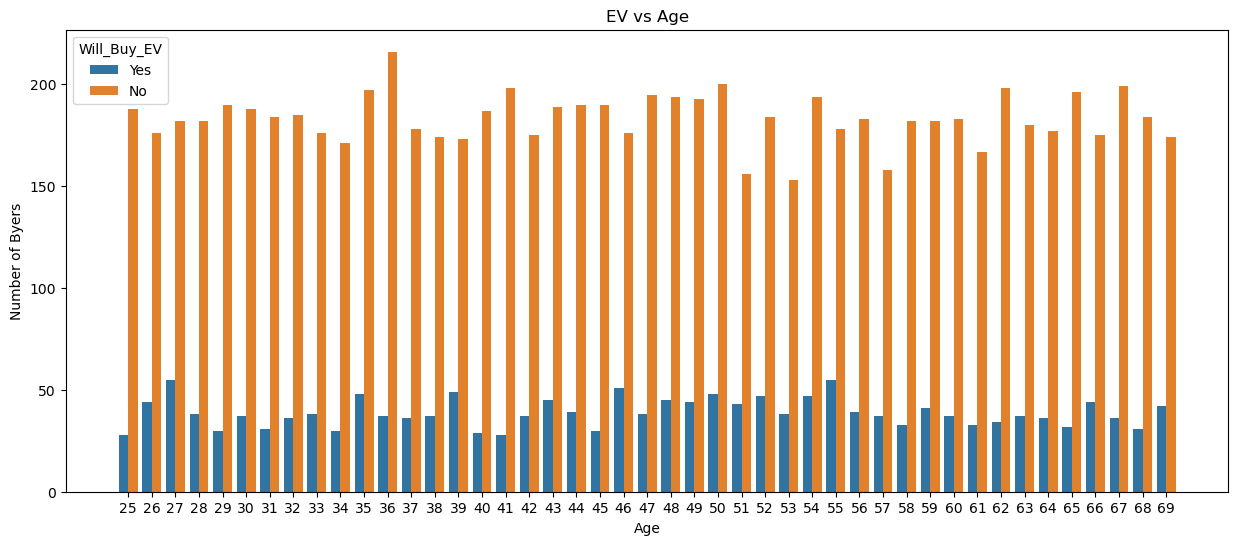

In [16]:
' 2. Which age group buys most ? '

plt.figure(figsize=(15, 6))

sns.countplot(data=df, x='Age', hue='Will_Buy_EV')

plt.title('EV vs Age')
plt.xlabel('Age')
plt.ylabel('Number of Byers')

plt.plot()

Constantly moving the EV purchase along all age groups

[]

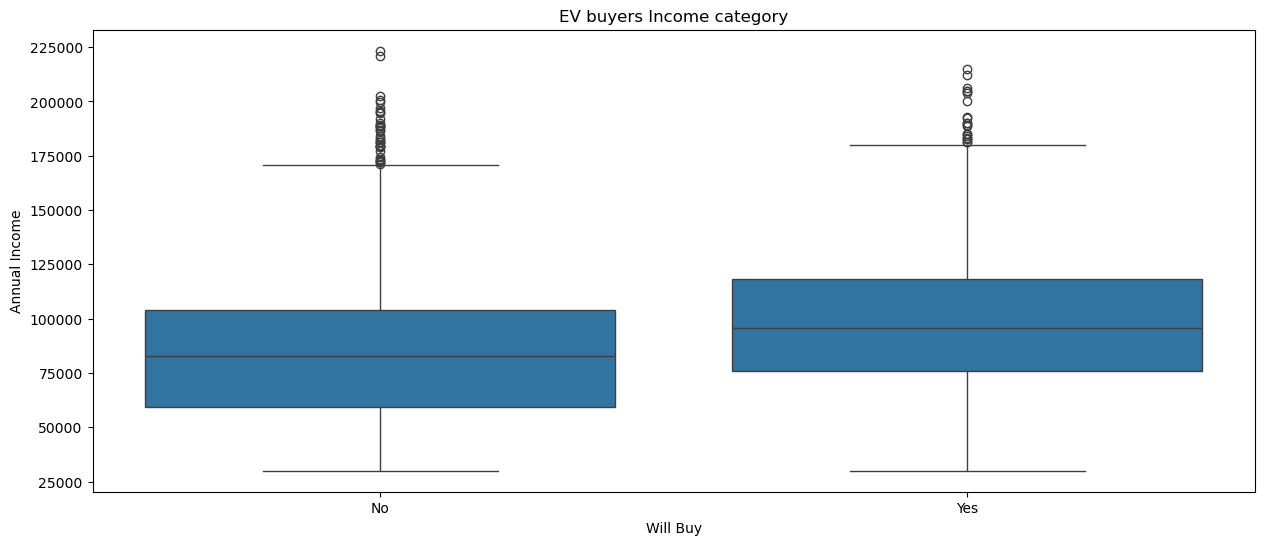

In [17]:
' 3. Does income differ between EV buyers and non-buyers? '

plt.figure(figsize=(15, 6))

sns.boxplot(data=df, x='Will_Buy_EV', y='Annual_Income_USD')

plt.title('EV buyers Income category')
plt.xlabel('Will Buy')
plt.ylabel('Annual Income')

plt.plot()

Only a slight diffrences among EV buyers and non buyers

[]

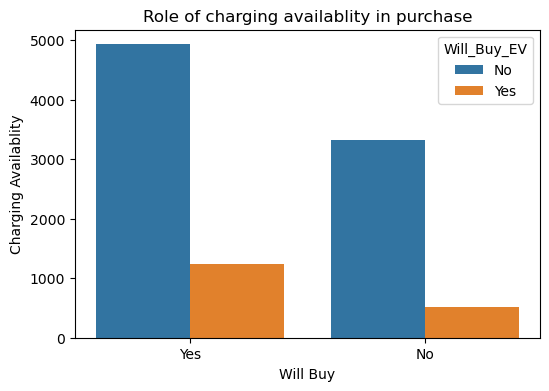

In [18]:
"4. Does home charging availability influence EV purchase intention? "

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Home_Charging_Possible',
    hue='Will_Buy_EV'
)

plt.title('Role of charging availablity in purchase')
plt.xlabel('Will Buy')
plt.ylabel('Charging Availablity')

plt.plot()

EV purchase rate affects only at a moderate rate based on charging availablity

[]

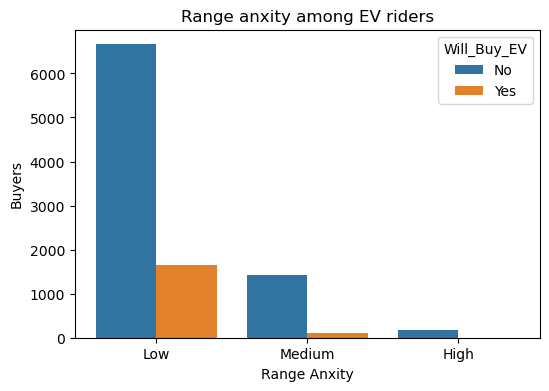

In [19]:
' 5. Does range anxiety affect EV purchase intention? '

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x='Range_Anxiety_Level',
    hue='Will_Buy_EV'
)

plt.title('Range anxity among EV riders')
plt.xlabel('Range Anxity')
plt.ylabel('Buyers')

plt.plot()

For a low range EV users Range Anxity Strongly affect the descicion to buy EV or not.

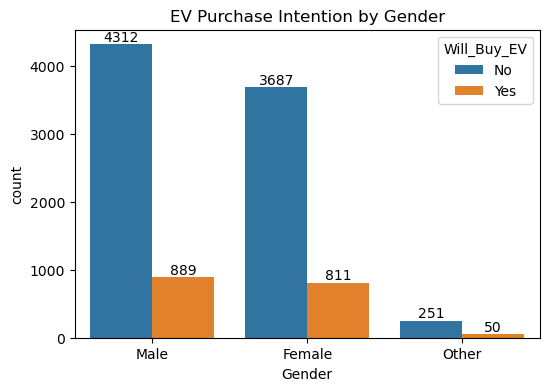

In [20]:
' 6. Does gender affect purchase intention? '

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Gender', hue='Will_Buy_EV')
plt.title('EV Purchase Intention by Gender')
for item in ax.containers:
    ax.bar_label(item)
plt.show()

Gender has almost no effect on whether someone wants an electric vehicle (EV).

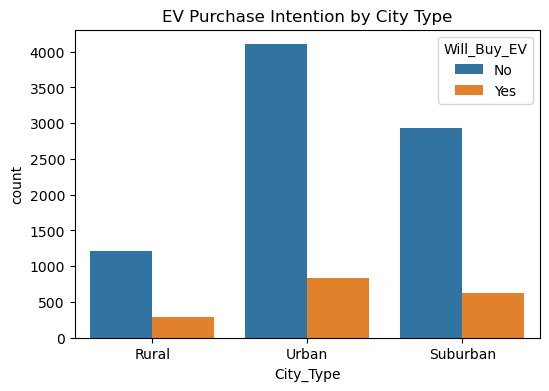

City_Type
Rural       0.190
Suburban    0.177
Urban       0.169
Name: Buy_Flag, dtype: float64


In [21]:
' 7. Does city type affect purchase intention? '

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='City_Type', hue='Will_Buy_EV')
plt.title('EV Purchase Intention by City Type')
plt.show()

print(df.groupby('City_Type')['Buy_Flag'].mean().round(3))

Only a small gradient but not a strong effect

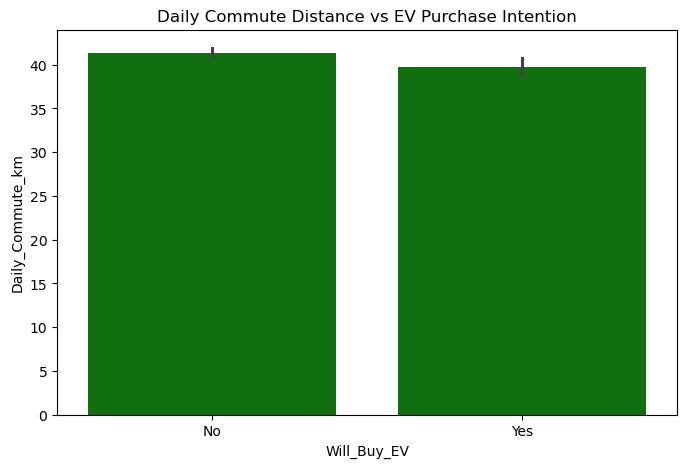

Will_Buy_EV
No     40.2
Yes    39.4
Name: Daily_Commute_km, dtype: float64


In [22]:
' 8. Does daily commute distance affect purchase intention? '
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Will_Buy_EV', y='Daily_Commute_km',color='green')
plt.title('Daily Commute Distance vs EV Purchase Intention')
plt.show()

print(df.groupby('Will_Buy_EV')['Daily_Commute_km'].median())

Essentially no difference — commute distance does not predict purchase intent in this dataset, despite being an intuitive assumption.

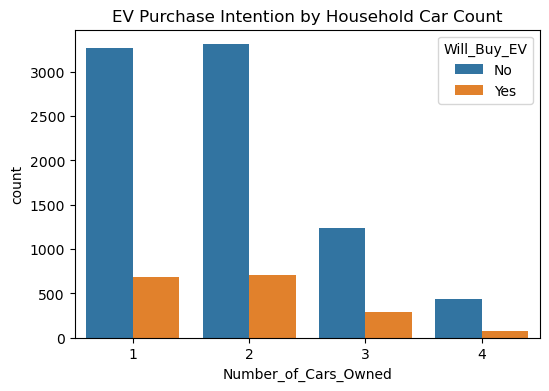

Number_of_Cars_Owned
1    0.173
2    0.176
3    0.187
4    0.149
Name: Buy_Flag, dtype: float64


In [23]:
" 9. Does the number of cars a household owns affect purchase intention? "
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Number_of_Cars_Owned', hue='Will_Buy_EV')
plt.title('EV Purchase Intention by Household Car Count')
plt.show()

print(df.groupby('Number_of_Cars_Owned')['Buy_Flag'].mean().round(3))

No clear pattern like a noisy data

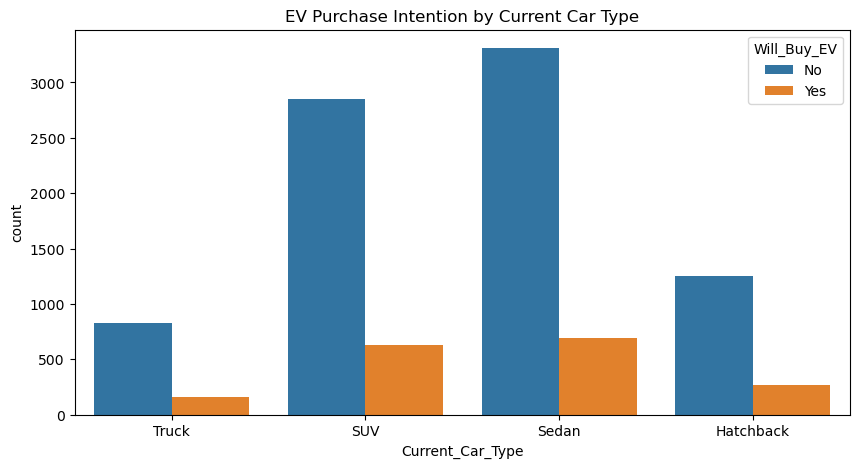

Current_Car_Type
SUV          0.181
Hatchback    0.175
Sedan        0.172
Truck        0.165
Name: Buy_Flag, dtype: float64


In [38]:
'10. Does current car type influence EV purchase intention?'
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='Current_Car_Type', hue='Will_Buy_EV')
plt.title('EV Purchase Intention by Current Car Type')
plt.show()

print(df.groupby('Current_Car_Type')['Buy_Flag'].mean().round(3).sort_values(ascending=False))

Almost a constant pattern among car type

## Charging Infrastructure & Incentives

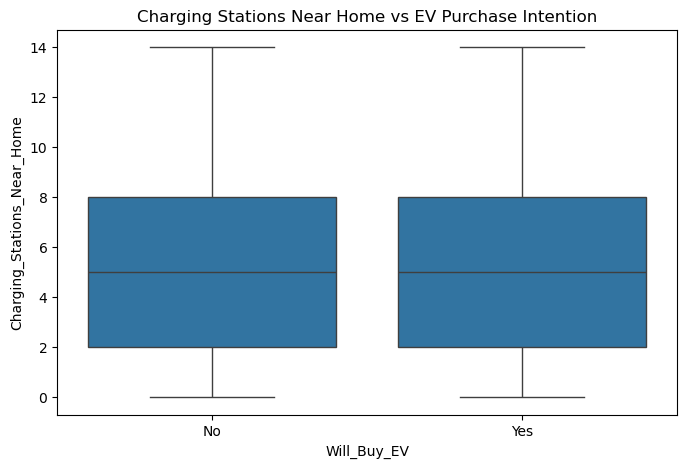

Will_Buy_EV
No     5.352121
Yes    5.322286
Name: Charging_Stations_Near_Home, dtype: float64


In [39]:
'11. Do nearby charging stations (home) affect purchase intention?'
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Home')
plt.title('Charging Stations Near Home vs EV Purchase Intention')
plt.show()

print(df.groupby('Will_Buy_EV')['Charging_Stations_Near_Home'].mean())

5.32 (buyers) vs. 5.35 (non-buyers) average nearby stations. 
No effect — despite being an intuitive assumption, station count near home does not predict purchase intent here.

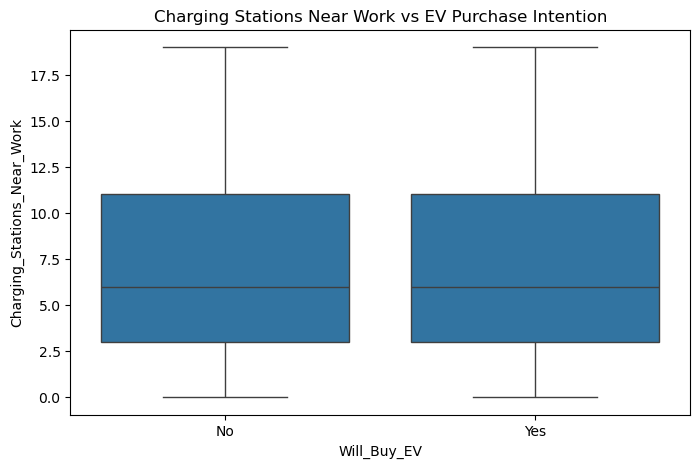

Will_Buy_EV
No     7.455152
Yes    7.472571
Name: Charging_Stations_Near_Work, dtype: float64


In [40]:
'12. Do nearby charging stations (work) affect purchase intention?'
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Will_Buy_EV', y='Charging_Stations_Near_Work')
plt.title('Charging Stations Near Work vs EV Purchase Intention')
plt.show()

print(df.groupby('Will_Buy_EV')['Charging_Stations_Near_Work'].mean())

Similar as above charging station near work has no role in purchase intention

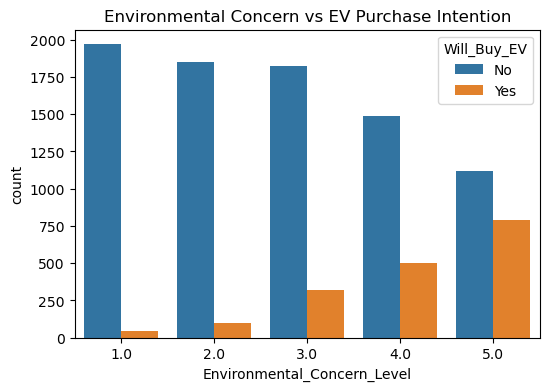

Will_Buy_EV
No     2.749091
Yes    4.086286
Name: Environmental_Concern_Level, dtype: float64


In [41]:
' 14. Does environmental concern level affect purchase intention? '
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='Environmental_Concern_Level', hue='Will_Buy_EV')
plt.title('Environmental Concern vs EV Purchase Intention')
plt.show()

print(df.groupby('Will_Buy_EV')['Environmental_Concern_Level'].mean())

Enviornmental Concern directly influence buyers to prefer

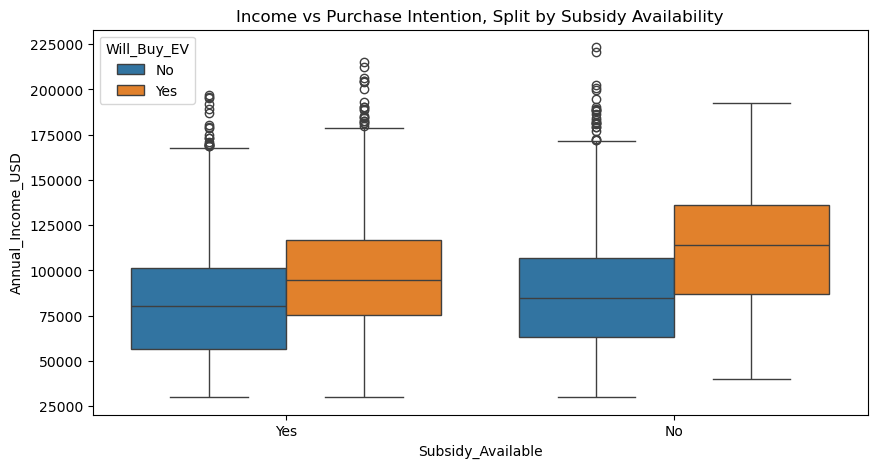

In [42]:
'15. Does a subsidy change the income threshold at which people buy?'
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Subsidy_Available', y='Annual_Income_USD', hue='Will_Buy_EV')
plt.title('Income vs Purchase Intention, Split by Subsidy Availability')
plt.show()

The subsidy has negatively influence the buyers to buy EV

In [43]:
' 16. Does city type predict home-charging feasibility (a confound check)? '
print(pd.crosstab(df['City_Type'], df['Home_Charging_Possible'], normalize='index'))

Home_Charging_Possible        No       Yes
City_Type                                 
Rural                   0.091578  0.908422
Suburban                0.203200  0.796800
Urban                   0.602307  0.397693


In Urban areas home charging facilities matter but Rural and Suburban region this cannot matter

In [44]:
' 17. Correlation ranking across all numeric fields (properly encoded)? '

numeric_cols = ['Age','Annual_Income_USD','Daily_Commute_km','Number_of_Cars_Owned',
                 'Charging_Stations_Near_Home','Charging_Stations_Near_Work',
                 'Environmental_Concern_Level','Range_Anxiety_Num','Subsidy_Flag','HomeCharge_Flag']

corr = df[numeric_cols + ['Buy_Flag']].corr()['Buy_Flag'].drop('Buy_Flag')
print(corr.sort_values(key=abs, ascending=False))

Environmental_Concern_Level    0.362754
Subsidy_Flag                   0.321147
Annual_Income_USD              0.173300
Range_Anxiety_Num             -0.137802
HomeCharge_Flag                0.085768
Daily_Commute_km              -0.026742
Age                            0.004303
Charging_Stations_Near_Home   -0.002800
Charging_Stations_Near_Work    0.001259
Number_of_Cars_Owned           0.000362
Name: Buy_Flag, dtype: float64


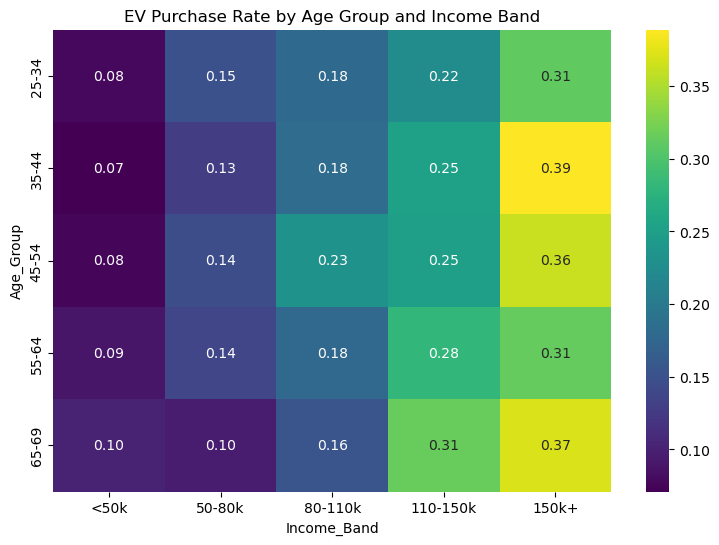

In [45]:
' 18. Buy-rate heatmap across Age × Income bands ? '

df['Age_Group'] = pd.cut(df['Age'], bins=[24,34,44,54,64,70],
                          labels=['25-34','35-44','45-54','55-64','65-69'])
df['Income_Band'] = pd.cut(df['Annual_Income_USD'],
                            bins=[0,50000,80000,110000,150000,250000],
                            labels=['<50k','50-80k','80-110k','110-150k','150k+'])

pivot = df.pivot_table(values='Buy_Flag', index='Age_Group', columns='Income_Band', aggfunc='mean')
plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title('EV Purchase Rate by Age Group and Income Band')
plt.show()

In [46]:
' 19. What does an "ideal buyer profile" look like? '

ideal = df[
    (df['Environmental_Concern_Level'] >= df['Environmental_Concern_Level'].median()) &
    (df['Subsidy_Available'] == 'Yes') &
    (df['Home_Charging_Possible'] == 'Yes')
]
print("Buy rate for this profile:", ideal['Buy_Flag'].mean())
print("Buy rate overall:", df['Buy_Flag'].mean())
print("Customers matching this profile:", len(ideal))

Buy rate for this profile: 0.46465968586387435
Buy rate overall: 0.175
Customers matching this profile: 2292


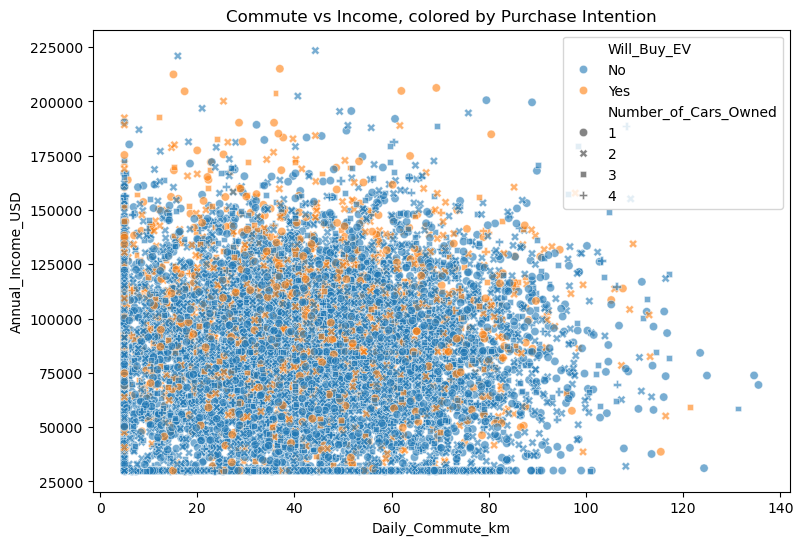

In [48]:
' 20. Does owning more cars change how commute distance affects buying? '

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Daily_Commute_km', y='Annual_Income_USD',
                 hue='Will_Buy_EV', style='Number_of_Cars_Owned', alpha=0.6)
plt.title('Commute vs Income, colored by Purchase Intention')
plt.show()

In [49]:
"22. What's the overall profile difference between buyers and non-buyers, in one shot?"
df.groupby('Will_Buy_EV').mean(numeric_only=True)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Buy_Flag,Subsidy_Flag,HomeCharge_Flag,Range_Anxiety_Num
Will_Buy_EV,,,,,,,,,,,
No,46.910545,82769.044121,41.374012,1.859758,5.352121,7.455152,2.749091,0.0,0.528364,0.597091,0.212970
Yes,47.057143,97611.941714,39.745543,1.860571,5.322286,7.472571,4.086286,1.0,0.942286,0.706857,0.057143


In [50]:
'23. Does having both subsidy AND high environmental concern matter more than either alone? '
both = df[(df['Subsidy_Available']=='Yes') & (df['Environmental_Concern_Level']>=4)]
print(both['Buy_Flag'].mean())
print(df['Buy_Flag'].mean())

0.5160875160875161
0.175


In [51]:
"24. Sanity check: does your cleaned dataset still add up? "
print(df.shape)
print(df['Will_Buy_EV'].value_counts())

(10000, 21)
Will_Buy_EV
No     8250
Yes    1750
Name: count, dtype: int64


### Suggestions and Recommendation

1. Focus on Subsidy Availability

Observation:
Subsidy availability has the strongest relationship with EV purchase intent. The buy rate is 27.4% for customers with a subsidy versus only 2.5% without a subsidy, an approximately 11× difference.

Recommendation:

Highlight available government or purchase subsidies prominently in marketing campaigns.
Make customers aware of their subsidy eligibility during the sales process.
Use subsidy availability as a primary factor in customer lead scoring.
Target customers who are eligible for subsidies with personalized offers.

2. Reduce Range Anxiety

Observation:
Range anxiety is one of the strongest barriers to EV adoption. The purchase rate falls from 19.9% for customers with low range anxiety to 6.4% for medium and only 0.6% for high range anxiety.

Recommendation:

Provide clear information about real-world EV driving range.
Offer range calculators to help customers estimate their daily requirements.
Promote warranty and roadside-assistance programs.
Educate customers about charging and long-distance travel.
Address range concerns directly during sales conversations.

3. Target Environmentally Conscious Customers

Observation:
Environmental concern shows a strong positive relationship with EV purchase intent. Buyers have an average environmental concern score of 4.09, compared with 2.75 among non-buyers.

Recommendation:

Develop marketing campaigns emphasizing environmental benefits.
Target customers with higher environmental concern scores.
Highlight reduced emissions and sustainability benefits.
Use environmentally focused messaging when promoting EV models.

4. Use Income as a Supporting Segmentation Factor

Observation:
Income has a meaningful positive relationship with EV purchase intent. The median income of buyers is $95,716, compared with $82,612 for non-buyers.

Recommendation:

Consider income as a supporting factor in customer segmentation.
Promote financing and affordability options to lower-income potential buyers.
Identify higher-income customers as a potentially valuable target segment.
Combine income with stronger factors such as subsidy eligibility and environmental concern rather than using income alone.

5. Improve Home-Charging Accessibility

Observation:
Customers who can charge at home have a 20.1% purchase rate, compared with 13.4% among customers without home-charging capability. This indicates a moderate positive effect.

Recommendation:

Promote home-charging solutions alongside EV sales.
Educate customers about the convenience of home charging.
Provide information about home-charger installation and compatibility.
Consider home-charging capability as a supporting factor in lead scoring.

6. Build a High-Potential Customer Lead Score

Observation:
Customers with high environmental concern, subsidy availability, and home-charging capability have a 46.5% purchase rate, substantially higher than the overall 17.5% purchase rate.

Recommendation:

Create a lead-scoring system using these three factors.
Prioritize high-scoring customers for sales follow-ups.
Use the combination of factors rather than relying on a single demographic variable.
Integrate the lead score into future customer-targeting campaigns.

7. Avoid Over-Relying on Weak Predictors

Observation:
Age, gender, commute distance, number of cars owned, current car type, and nearby charging-station counts showed little or no meaningful relationship with EV purchase intent.

Recommendation:

Avoid making these variables the primary basis for marketing decisions.
Focus resources on stronger factors such as subsidy availability, environmental concern, income, and range anxiety.
Continue monitoring these variables as additional customer data becomes available.
Overall Recommendation

The analysis suggests that EV adoption is driven more by financial incentives, environmental attitudes, and range-related concerns than by basic demographics or charging-station proximity.

The company should therefore prioritize:

Subsidy Awareness → Range Anxiety Reduction → Environmental Targeting → Home-Charging Support → Data-Driven Lead Scoring

This approach can help the company focus its marketing and sales efforts on customers who are more likely to purchase an EV, rather than relying on broad demographic targeting.